In [9]:
# Gradient Descent Variants
# 
# Comparing:
# 1. Batch Gradient Descent
# 2. Stochastic Gradient Descent (SGD)
# 3. Mini-Batch Gradient Descent
#
# Goal:
# Understand how each method updates weights and converges

In [10]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# Simple linear data
X = np.linspace(1, 10, 100)
y = 3*X + 5 + np.random.randn(100)*2

# reshape
X = X.reshape(-1, 1)

<function matplotlib.pyplot.show(close=None, block=None)>

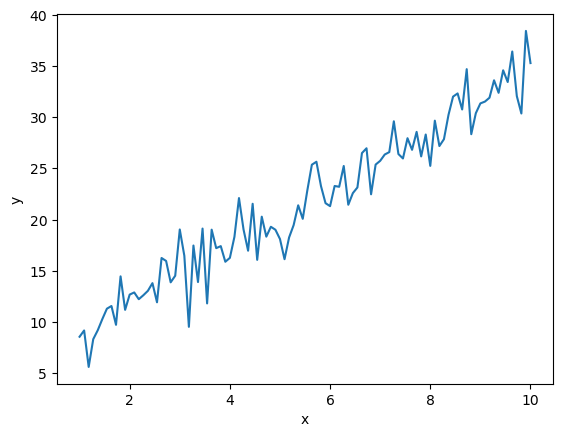

In [12]:
plt.plot(X,y)
plt.xlabel("x")
plt.ylabel("y")
plt.show

In [13]:
# add bias
X = np.c_[np.ones(X.shape[0]), X]

# parameters
lr = 0.01
epochs = 50

In [14]:
# Batch Gradient descent: Uses ALL data
w = np.zeros(X.shape[1])
batch_costs = []

for _ in range(epochs):
    preds = X @ w
    error = preds - y
    
    gradient = (1/len(y)) * (X.T @ error)
    w = w - lr * gradient
    
    cost = np.mean(error**2)
    batch_costs.append(cost)

In [15]:
# Stochastic Gradient Descent (SGD): Uses ONE data point
w = np.zeros(X.shape[1])
sgd_costs = []

for _ in range(epochs):
    for i in range(len(y)):
        xi = X[i].reshape(1, -1)
        yi = y[i]
        
        pred = xi @ w
        error = pred - yi
        
        gradient = xi.T * error
        w = w - lr * gradient.flatten()
    
    # full cost after epoch
    preds = X @ w
    cost = np.mean((preds - y)**2)
    sgd_costs.append(cost)

In [16]:
#  Mini-Batch Gradient Descent: Use small chunks
w = np.zeros(X.shape[1])
mini_costs = []
batch_size = 10

for _ in range(epochs):
    for i in range(0, len(y), batch_size):
        xi = X[i:i+batch_size]
        yi = y[i:i+batch_size]
        
        preds = xi @ w
        error = preds - yi
        
        gradient = (1/len(yi)) * (xi.T @ error)
        w = w - lr * gradient
    
    # full cost
    preds = X @ w
    cost = np.mean((preds - y)**2)
    mini_costs.append(cost)

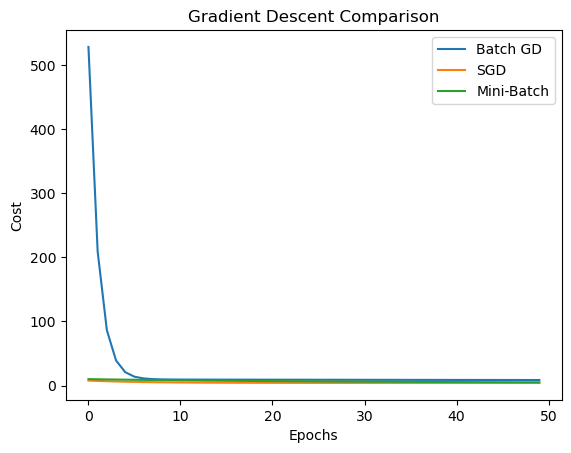

In [17]:
# Compareing all
plt.plot(batch_costs, label="Batch GD")
plt.plot(sgd_costs, label="SGD")
plt.plot(mini_costs, label="Mini-Batch")

plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.title("Gradient Descent Comparison")

plt.legend()
plt.show()